In [9]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [10]:
#Required libraries
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

In [11]:
# 1. Load the dataset
print("--- Loading Text Data ---")
df_nlp = pd.read_csv('3) Sentiment dataset.csv')

# Drop any rows where the 'Text' or 'Sentiment' might be null
df_nlp = df_nlp.dropna(subset=['Text', 'Sentiment'])

print(f"Data loaded successfully. Total rows to process: {len(df_nlp)}")
print("-" * 40)

--- Loading Text Data ---
Data loaded successfully. Total rows to process: 732
----------------------------------------



--- Generating Word Cloud ---


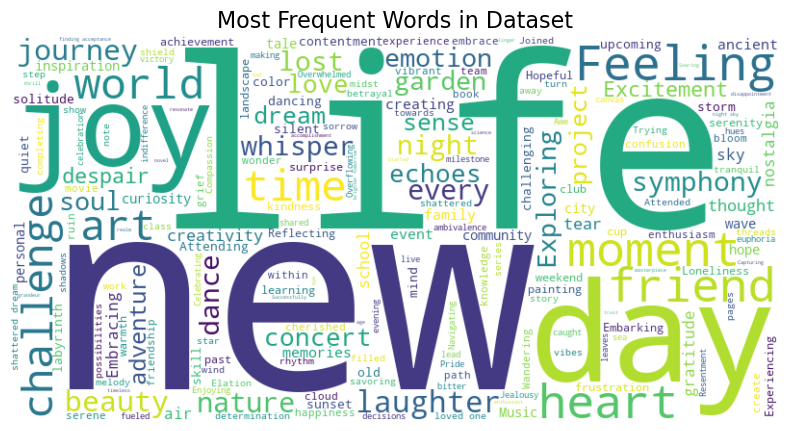

In [12]:
# WORD CLOUD GENERATION
print("\n--- Generating Word Cloud ---")

# Combine all the text into one giant string
all_text = " ".join(str(sentence) for sentence in df_nlp['Text'])

# Create and generate a word cloud image
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis', max_words=200).generate(all_text)

# Display the generated image
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Turn off the gridlines and numbers
plt.title('Most Frequent Words in Dataset', fontsize=16)
plt.show()

In [13]:
#TEXT CLASSIFICATION MODEL
print("\n--- Training NLP Classification Model ---")

# 1. Separate the features (Text) and the target (Sentiment)
X = df_nlp['Text'].astype(str)
y = df_nlp['Sentiment']

# 2. Convert the text into numbers using TF-IDF 
# We remove common 'stop_words' like "the", "and", "is" so the model focuses on important words
vectorizer = TfidfVectorizer(stop_words='english', max_features=3000)
X_vectorized = vectorizer.fit_transform(X)


--- Training NLP Classification Model ---


In [14]:
# Split into training and testing 
X_train, X_test, y_train, y_test = train_test_split(X_vectorized, y, test_size=0.2, random_state=42)

# Train a Naive Bayes Classifier 
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [15]:
# 5. Make predictions and evaluate the model
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\n--- NLP Model Evaluation ---")
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred))


--- NLP Model Evaluation ---
Model Accuracy: 10.20%

Detailed Classification Report:
                        precision    recall  f1-score   support

         Acceptance          0.00      0.00      0.00         2
           Admiration        0.00      0.00      0.00         1
        Admiration           0.00      0.00      0.00         1
         Affection           0.00      0.00      0.00         1
      Ambivalence            0.00      0.00      0.00         1
         Anger               0.00      0.00      0.00         1
        Anticipation         0.00      0.00      0.00         1
        Arousal              0.00      0.00      0.00         3
                  Awe        0.00      0.00      0.00         1
         Awe                 0.00      0.00      0.00         1
                  Bad        0.00      0.00      0.00         1
             Betrayal        0.00      0.00      0.00         2
        Betrayal             0.00      0.00      0.00         1
         Bitter  

c:\Users\bhatt\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\bhatt\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\bhatt\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
